In [1]:
import os
import warnings

import agama
import astropy
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, lognorm, norm
from sklearn.svm import SVC

In [2]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

in_situ_msk = True  # True for include in_situ
ex_situ_msk = False  # True for include ex_situ

snap = 600

In [3]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

In [4]:
agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

pot_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
pot_nbody = agama.Potential(pot_file)

r_lim = 3
xyz = np.array([r_lim, r_lim * 0, r_lim * 0])
vy = np.sqrt(-r_lim * pot_nbody.force(xyz)[0])
vxyz = np.array([0, vy, 0])
posvel = np.concatenate((xyz, vxyz))
t_3kpc = pot_nbody.Tcirc(posvel) * units["time"]

In [5]:
mw_fil = "../data/mw_gcs.csv"
df = pd.read_csv(mw_fil)

MW_pot = "../.venv312/lib/python3.12/site-packages/agama/data/MWPotential2014.ini"
pot_nbody = agama.Potential(MW_pot)

posvel = np.column_stack((df["X"], df["Y"], df["Z"], df["U"], df["V"], df["W"]))
result = agama.orbit(potential=pot_nbody, ic=posvel, time=10 * pot_nbody.Tcirc(posvel), trajsize=1000)

period = np.array([np.nan] * len(result))

for i in range(len(result)):
    result_i = result[i]

    t_i_agama = result_i[0]
    t_i_myr = t_i_agama * units["time"]  # Myr
    orb_i = result_i[1]

    if np.isnan(posvel[i]).any():
        continue

    r_i = np.linalg.norm(orb_i[:, 0:3], axis=1)

    peaks, _ = find_peaks(r_i)
    t_orb_i = np.mean(np.diff(t_i_myr[peaks]))

    period[i] = t_orb_i

df["t_Myr"] = period
df["t_Gyr"] = period / 1000

167 orbits complete (7952 orbits/s)


In [6]:
it_dict = {}
for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    amsk = src_dat["grpid"][()] == 0

    if (in_situ_msk) & (not ex_situ_msk):
        msk = amsk
    elif (not in_situ_msk) & (ex_situ_msk):
        msk = ~amsk
    else:
        msk = np.ones(len(amsk), dtype=bool)

    m_tfo = 10 ** src_dat["logm_tfor"][msk]
    m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][msk])

    m_tz0_log = src_dat["logm_tz0"][msk]
    m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

    tfor = src_dat["tfor"][msk]
    tdis = src_dat["tdis"][msk]

    age = time - tfor
    age_p = np.array([x - y if x != -1 else time - y for x, y in zip(tdis, tfor)])

    t_tz0 = src_dat["torb_600"][msk]
    s_tz0 = np.array(src_dat["s_flag"][msk], dtype=bool)

    ml = m_tfo_ev - m_tz0
    ml_rate = (m_tfo_ev - m_tz0) / age_p

    it_dict[it_id] = {}
    it_dict[it_id]["m_tfo"] = m_tfo
    it_dict[it_id]["m_tfo_ev"] = m_tfo_ev
    it_dict[it_id]["m_tz0"] = m_tz0
    it_dict[it_id]["tfor"] = tfor
    it_dict[it_id]["tdis"] = tdis
    it_dict[it_id]["age"] = age
    it_dict[it_id]["age_p"] = age_p
    it_dict[it_id]["t_tz0"] = t_tz0
    it_dict[it_id]["s_tz0"] = s_tz0
    it_dict[it_id]["ml"] = ml
    it_dict[it_id]["ml_rate"] = ml_rate

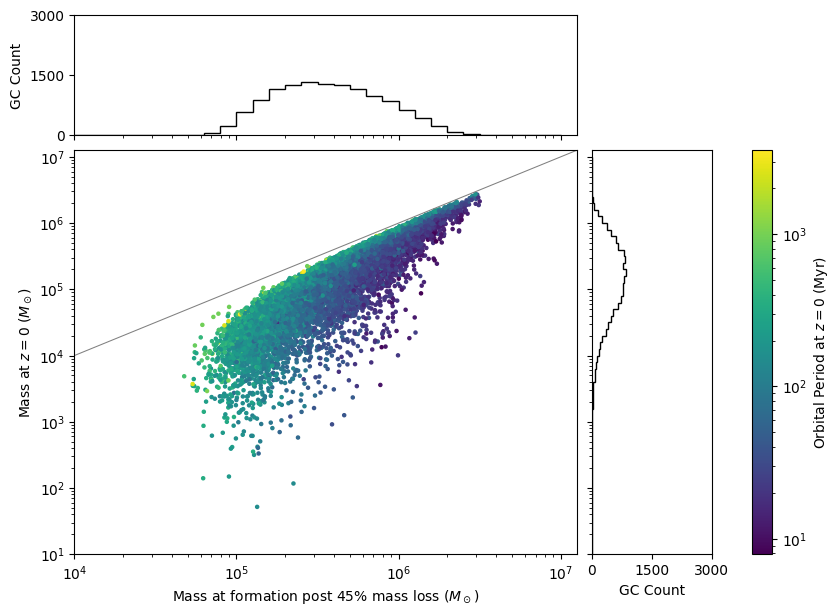

In [7]:
x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]

    x_i = it_dict[it_id]["m_tfo_ev"][msk_i]
    y_i = it_dict[it_id]["m_tz0"][msk_i]
    c_i = it_dict[it_id]["t_tz0"][msk_i]

    x = np.concatenate((x, x_i))
    y = np.concatenate((y, y_i))
    c = np.concatenate((c, c_i))

# Create main figure and scatter axes
fig, ax_scatter = plt.subplots(figsize=(9, 7))

# Create divider for colorbar and histograms
divider = make_axes_locatable(ax_scatter)
ax_histx = divider.append_axes("top", 1.2, pad=0.15, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.2, pad=0.15, sharey=ax_scatter)
ax_cb = divider.append_axes("right", 0.2, pad=0.4)

sc = ax_scatter.scatter(x, y, c=c, cmap="viridis", s=5, norm=LogNorm())

ax_scatter.set_xlabel(r"Mass at formation post 45% mass loss ($M_\odot$)")
ax_scatter.set_ylabel(r"Mass at $z=0$ ($M_\odot$)")
ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")
ax_scatter.set_xlim([10**4, 10**7.1])
ax_scatter.set_ylim([10**1, 10**7.1])

x_fit = np.logspace(4, 7.1)
ax_scatter.plot(x_fit, x_fit, c="grey", lw=0.75)
# ax_scatter.plot(x_fit, 0.55 * x_fit, c="grey", lw=0.75, ls="--")

histx_bins = np.logspace(4, 7, 31)
ax_histx.hist(x, bins=histx_bins, color="k", histtype="step")
ax_histx.tick_params(labelbottom=False)
ax_histx.set_ylabel("GC Count")
# ax_histx.set_yscale("log")
ax_histx.set_ylim([0, 3000])
ax_histx.set_yticks([0, 1500, 3000])

histy_bins = np.logspace(1, 7, 61)
ax_histy.hist(y, bins=histy_bins, orientation="horizontal", color="k", histtype="step")
ax_histy.tick_params(labelleft=False)
ax_histy.set_xlabel("GC Count")
# ax_histy.set_xscale("log")
ax_histy.set_xlim([0, 3000])
ax_histy.set_xticks([0, 1500, 3000])

cb = plt.colorbar(sc, cax=ax_cb)
cb.set_label(r"Orbital Period at $z=0$ (Myr)")

Text(0, 0.5, 'Orbital Period at $z=0$ (Myr)')

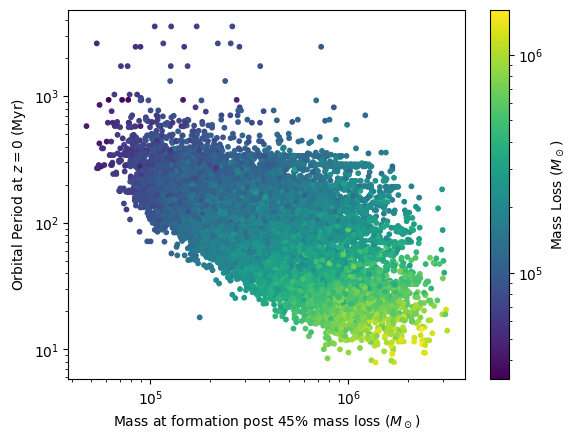

In [8]:
x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]
    x_i = it_dict[it_id]["m_tfo_ev"][msk_i]
    y_i = it_dict[it_id]["t_tz0"][msk_i]
    # c_i = it_dict[it_id]["m_tz0"][msk_i]
    c_i = it_dict[it_id]["ml"][msk_i]

    x = np.concatenate((x, x_i))
    y = np.concatenate((y, y_i))
    c = np.concatenate((c, c_i))

plt.scatter(x, y, c=c, norm=LogNorm(), s=10)
# plt.colorbar(label=r"Mass at $z=0$ ($M_\odot$)")
plt.colorbar(label=r"Mass Loss ($M_\odot$)")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass at formation post 45% mass loss ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

(3.9810717055349722, 5011.872336272725)

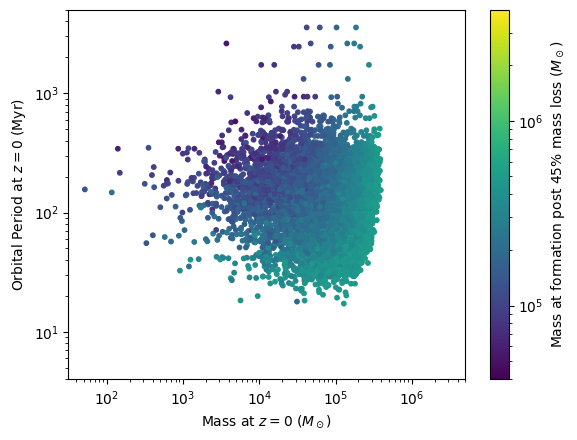

In [9]:
x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]
    msk_i = msk_i & (it_dict[it_id]["m_tfo_ev"] < 10**5.7)
    x_i = it_dict[it_id]["m_tz0"][msk_i]
    y_i = it_dict[it_id]["t_tz0"][msk_i]
    c_i = it_dict[it_id]["m_tfo_ev"][msk_i]
    # c_i = it_dict[it_id]["ml"][msk_i]

    x = np.concatenate((x, x_i))
    y = np.concatenate((y, y_i))
    c = np.concatenate((c, c_i))

plt.scatter(x, y, c=c, norm=LogNorm(vmin=10**4.6, vmax=10**6.6), s=10)
plt.colorbar(label=r"Mass at formation post 45% mass loss ($M_\odot$)")
# plt.scatter(x, y, c=c, norm=LogNorm(), s=10)
# plt.colorbar(label=r"Mass Loss ($M_\odot$)")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass at $z=0$ ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

plt.xlim(10**1.5, 10**6.7)
plt.ylim(10**0.6, 10**3.7)

In [10]:
# example plot
it_id = "it001"
make_gif = False

snap_dict = {}
src_dat = ghost_data[it_id]["source"]
src_gcs = src_dat["gcid"][()]

# snp_id = "snap026"
for snp_id in ghost_data[it_id]["snapshots"].keys():
    snp_dat = ghost_data[it_id]["snapshots"][snp_id]
    snp_gcs = snp_dat["gcid"][()]
    snp_mas = 10 ** snp_dat["logm"][()]

    t_z0 = []
    for gc in snp_gcs:
        gcidx = np.where(src_gcs == gc)[0][0]
        t_z0.append(src_dat["torb_600"][gcidx])
    t_z0 = np.array(t_z0)

    snap_dict[snp_id] = {"x": snp_mas, "y": t_z0}


if make_gif:
    metadata = dict(title="t0_mass_trends", artist="Finn")
    writer = PillowWriter(fps=2, metadata=metadata)

    fig = plt.figure(figsize=(8, 6))

    gif_loc = sim_dir + sim + "/gifs/"
    if not os.path.exists(gif_loc):
        os.makedirs(gif_loc)

    gif_file = gif_loc + it_id + "_t0_mass.gif"
    with writer.saving(fig, gif_file, 100):
        for snp_id in snap_dict.keys():
            fig_shape = (1, 1)
            ax = plt.subplot2grid(shape=fig_shape, loc=(0, 0))

            x = snap_dict[snp_id]["x"]
            y = snap_dict[snp_id]["y"]

            snp = int(snp_id[4:])
            t_snp = pub_data["time_Gyr"][pub_data["index"] == snp].values[0]
            t_snp = np.round(t_snp, 4)

            sc = ax.scatter(x, y, c="r", s=10)

            ax.set_xlabel(r"GC Mass at Snap [M$_{\odot}$]")
            ax.set_ylabel(r"Orbital Period at $z=0$ (Myr)")

            ax.set_xscale("log")
            ax.set_yscale("log")

            ax.set_xlim(10**1.6, 10**7)
            ax.set_ylim(10**0.4, 10**4.2)

            time_stamp = "Time: " + str(t_snp) + " Gyr"
            ax.text(
                0.70,
                0.95,
                time_stamp,
                color="black",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=12,
            )

            writer.grab_frame()
            fig.clear()

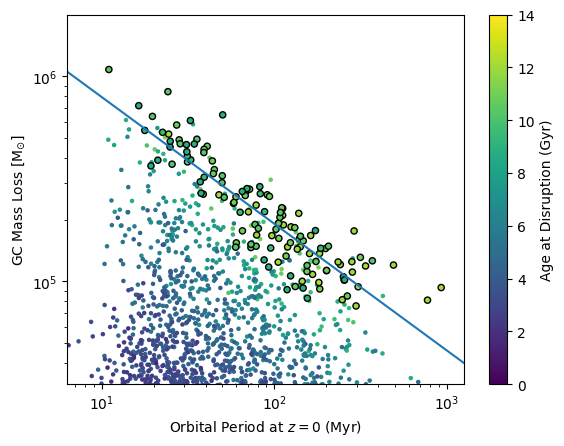

In [11]:
# example plot

it_id = "it001"

msk_i = it_dict[it_id]["s_tz0"]
x_i = it_dict[it_id]["t_tz0"][msk_i]
y_i = it_dict[it_id]["ml"][msk_i]
# y_i = it_dict[it_id]["ml_rate"][msk_i]
c_i = it_dict[it_id]["m_tz0"][msk_i]
c_i = it_dict[it_id]["age_p"][msk_i]

# plt.scatter(x_i, y_i, c=c_i, norm=LogNorm())
plt.scatter(x_i, y_i, c=c_i, vmin=0, vmax=14, ec="k", s=20)
# plt.colorbar(label=r"Mass at $z=0$ (M$_{\odot}$)")
plt.colorbar(label=r"Age at Disruption (Gyr)")

plt.xscale("log")
plt.yscale("log")

plt.xlim(10**0.8, 10**3.1)
plt.ylim(10**4.5, 10**6.3)
# plt.ylim(10**3.5, 10**5.3)

plt.xlabel(r"Orbital Period at $z=0$ (Myr)")
plt.ylabel(r"GC Mass Loss [M$_{\odot}$]")
# plt.ylabel(r"GC Mass Loss Rate (M$_{\odot}$ / Gyr)")

x_fit = np.logspace(0.8, 3.1)
x_fit_log = np.log10(x_fit)

res = stats.linregress(np.log10(x_i), np.log10(y_i))
y_fit_log = res.slope * x_fit_log + res.intercept
y_fit = 10**y_fit_log

plt.plot(x_fit, y_fit)

x_i = it_dict[it_id]["t_tz0"][~msk_i]
y_i = it_dict[it_id]["ml"][~msk_i]
# y_i = it_dict[it_id]["ml_rate"][~msk_i]
c_i = it_dict[it_id]["age_p"][~msk_i]
# plt.scatter(x_i, y_i, c="k", s=5, zorder=0)
plt.scatter(x_i, y_i, c=c_i, s=5, zorder=0, vmin=0, vmax=14)


In [12]:
slope_lst = []
inter_lst = []

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]
    x_i = it_dict[it_id]["t_tz0"][msk_i]
    y_i = it_dict[it_id]["ml"][msk_i]
    y_i = it_dict[it_id]["ml_rate"][msk_i]

    res = stats.linregress(np.log10(x_i), np.log10(y_i))
    slope_lst.append(res.slope)
    inter_lst.append(res.intercept)

m = np.mean(slope_lst)
dm = np.std(slope_lst)

c = np.mean(inter_lst)
dc = np.std(inter_lst)

slope = str(np.round(m, 2)) + "+/-" + str(np.round(dm, 2))
inter = str(np.round(c, 2)) + "+/-" + str(np.round(dc, 2))

print("log y = (" + slope + ") log x + (" + inter + ")")

log y = (-0.7+/-0.04) log x + (5.66+/-0.09)


In [13]:
fit_dict = {}
for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]
    x_is = it_dict[it_id]["m_tfo_ev"][msk_i]
    y_is = it_dict[it_id]["t_tz0"][msk_i]

    x_id = it_dict[it_id]["m_tfo_ev"][~msk_i]
    y_id = it_dict[it_id]["t_tz0"][~msk_i]

    # Stack features in log10 space
    Xd = np.stack((np.log10(x_id), np.log10(y_id)), axis=1)
    Xs = np.stack((np.log10(x_is), np.log10(y_is)), axis=1)
    Xds = np.vstack((Xd, Xs))

    y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

    # Train linear SVM
    clf = SVC(kernel="linear")
    clf.fit(Xds, y)

    # Decision boundary in log10 space
    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    fit_dict[it_id] = {"m": m, "c": c}

In [14]:
m = np.mean([fit_dict[it_id]["m"] for it_id in fit_dict.keys()])
dm = np.std([fit_dict[it_id]["m"] for it_id in fit_dict.keys()])

c = np.mean([fit_dict[it_id]["c"] for it_id in fit_dict.keys()])
dc = np.std([fit_dict[it_id]["c"] for it_id in fit_dict.keys()])

slope = str(np.round(m, 2)) + "+/-" + str(np.round(dm, 2))
inter = str(np.round(c, 2)) + "+/-" + str(np.round(dc, 2))

print("log y = (" + slope + ") log x + (" + inter + ")")

log y = (-1.5+/-0.11) log x + (9.99+/-0.58)


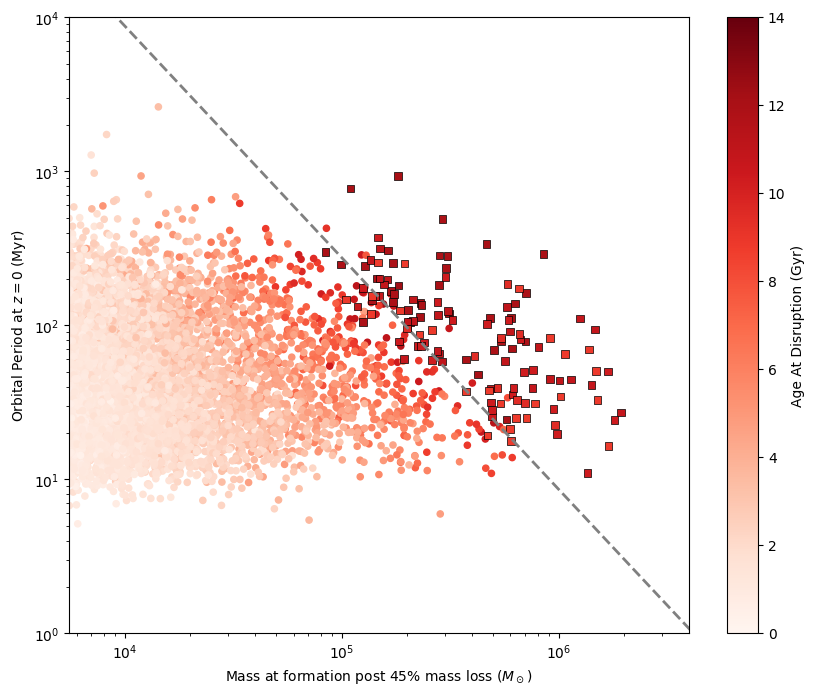

In [15]:
it_id = "it001"

msk_i = it_dict[it_id]["s_tz0"]

x_is = it_dict[it_id]["m_tfo_ev"][msk_i]
y_is = it_dict[it_id]["t_tz0"][msk_i]
c_is = it_dict[it_id]["age_p"][msk_i]

x_id = it_dict[it_id]["m_tfo_ev"][~msk_i]
y_id = it_dict[it_id]["t_tz0"][~msk_i]
c_id = it_dict[it_id]["age_p"][~msk_i]

plt.figure(figsize=(10, 8))
plt.scatter(x_is, y_is, c=c_is, s=30, cmap="Reds", vmin=0, vmax=14, ec="k", lw=0.5, marker="s")
plt.scatter(x_id, y_id, c=c_id, s=20, cmap="Reds", vmin=0, vmax=14, zorder=0)
plt.colorbar(label="Age At Disruption (Gyr)")

plt.xscale("log")
plt.yscale("log")

plt.xlim(0.55 * 10**4, 10**6.6)
plt.ylim(10**0, 10**4)

plt.xlabel(r"Mass at formation post 45% mass loss ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

xfit = np.logspace(3, 7)
xfitlog = np.log10(xfit)

yfitlog = xfitlog * fit_dict[it_id]["m"] + fit_dict[it_id]["c"]
yfit = 10**yfitlog

plt.plot(xfit, yfit, c="grey", ls="--", lw=2)

In [16]:
def plot_lim(x, y, msk):
    x_is = x[msk]
    y_is = y[msk]

    x_id = x[~msk]
    y_id = y[~msk]

    # Stack features in log10 space
    Xd = np.stack((np.log10(x_id), np.log10(y_id)), axis=1)
    Xs = np.stack((np.log10(x_is), np.log10(y_is)), axis=1)
    Xds = np.vstack((Xd, Xs))

    y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

    # Train linear SVM
    clf = SVC(kernel="linear")
    clf.fit(Xds, y)

    # Decision boundary in log10 space
    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c


def life_cut(x, y, c, c_level, xfitlog, plot=True, ytlog=0.7, label=None):
    msk = c <= c_level
    m, b = plot_lim(x, y, msk)

    yfitlog = m * xfitlog + b
    yfit = 10**yfitlog

    if not plot:
        return yfit

    if label is None:
        label = f"{c_level} Gyr"
    plt.plot(xfit, yfit, c="grey", ls="--")

    # --- label position (on the line) ---
    xtlog = (ytlog - b) / m
    # x0, y0 = 10**xtlog, 10**ytlog

    ax = plt.gca()

    # compute screen-space angle
    dx = 0.1
    x1log, x2log = xtlog, xtlog + dx
    y1log = m * x1log + b
    y2log = m * x2log + b

    p1 = ax.transData.transform((10**x1log, 10**y1log))
    p2 = ax.transData.transform((10**x2log, 10**y2log))

    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    # --- offset perpendicular to the line (in pixels) ---
    offset_pixels = 17  # increase for more separation

    normal = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
    normal = normal / np.linalg.norm(normal)

    p_text = p1 + offset_pixels * normal

    # convert back to data coords
    x_text, y_text = ax.transData.inverted().transform(p_text)

    plt.text(
        x_text,
        y_text,
        label,
        rotation=angle,
        rotation_mode="anchor",
        ha="left",
        va="top",
        color="grey",
        bbox=dict(facecolor="none", alpha=0.6, edgecolor="none"),
        zorder=5,
    )


def lower_envelope(x, m, x_b, y_b):
    return np.where(x < x_b, m * (x - x_b) + y_b, y_b)


def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level


def plot_bounding(it_dict, fraction=0.98):
    x = np.array([])
    y = np.array([])
    # c = np.array([])

    for it_id in it_dict.keys():
        msk_i = it_dict[it_id]["s_tz0"]
        x_i = it_dict[it_id]["m_tz0"][msk_i]
        y_i = it_dict[it_id]["t_tz0"][msk_i]
        # c_i = it_dict[it_id]["ml"][msk_i]
        # c_i = it_dict[it_id]["age_p"][msk_i]

        x = np.concatenate((x, x_i))
        y = np.concatenate((y, y_i))
        # c = np.concatenate((c, c_i))

    xlog = np.log10(x)
    ylog = np.log10(y)

    xy = np.vstack([xlog, ylog])
    kde = gaussian_kde(xy)
    xmin, xmax = xlog.min(), xlog.max()
    ymin, ymax = ylog.min(), ylog.max()

    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    level = kde_threshold(Z, fraction)
    cont = plt.contour(X, Y, Z, levels=[level], colors="orange")
    plt.close()

    contour_path = cont.collections[0].get_paths()[0]
    vertices = contour_path.vertices
    x_contour, y_contour = vertices[:, 0], vertices[:, 1]

    # --- Keep only the "lower" part of the contour ---
    # We'll bin x values and take the minimum y in each bin
    bins = np.linspace(x_contour.min(), x_contour.max(), 100)
    x_bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_lower = []
    x_lower = []

    for i in range(len(bins) - 1):
        mask = (x_contour >= bins[i]) & (x_contour < bins[i + 1])
        if np.any(mask):
            x_lower.append(x_bin_centers[i])
            y_lower.append(np.min(y_contour[mask]))

    x_lower = np.array(x_lower)
    y_lower = np.array(y_lower)

    # --- Fit lower-envelope function ---
    p0 = [-1, np.median(x_lower), np.median(y_lower)]  # initial guess: slope, x_b, y_b
    params, cov = curve_fit(lower_envelope, x_lower, y_lower, p0=p0)

    xfit = np.logspace(1, 7)
    xfitlog = np.log10(xfit)
    yfitlog = lower_envelope(xfitlog, *params)
    yfit = 10**yfitlog

    plot_dict = {"xfit": xfit, "yfit": yfit, "params": params, "cov": cov}

    return plot_dict

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_90070/3640124667.py:130: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = cont.collections[0].get_paths()[0]


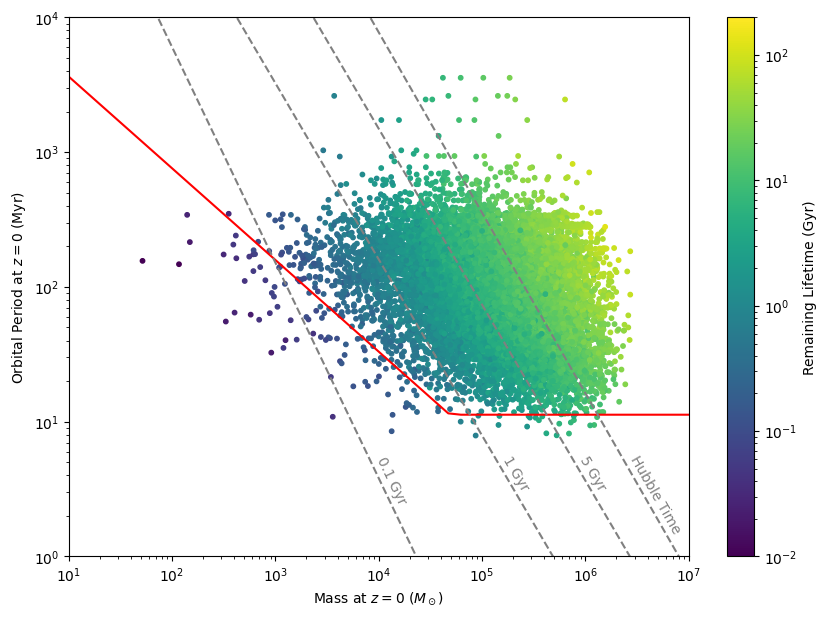

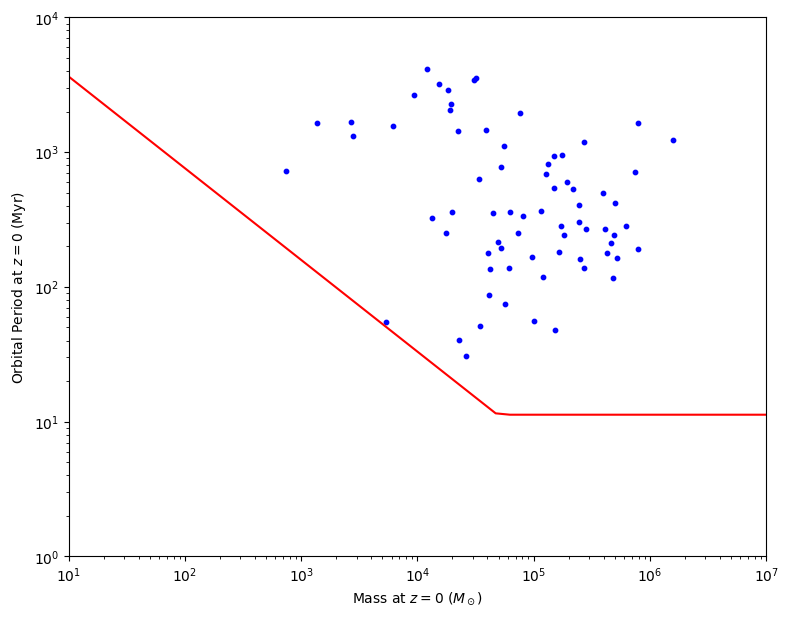

In [40]:
boundary = True
birth_lim = False
turn_off_mass = False

x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]
    x_i = it_dict[it_id]["m_tz0"][msk_i]
    y_i = it_dict[it_id]["t_tz0"][msk_i]
    ml_rate_i = it_dict[it_id]["ml_rate"][msk_i]

    c_i = x_i / ml_rate_i

    x = np.concatenate((x, x_i))
    y = np.concatenate((y, y_i))
    c = np.concatenate((c, c_i))

if boundary:
    plot_dict = plot_bounding(it_dict, fraction=0.98)

plt.figure(figsize=(10, 7))

if boundary:
    plt.plot(plot_dict["xfit"], plot_dict["yfit"], c="r")

    # if turn_off_mass:
    #     mt = 10 ** plot_dict["params"][1]
    #     plt.plot([mt, mt], [10**0, 10**4], c="orange", ls=":", lw=1)


plt.scatter(x, y, c=c, s=10, norm=LogNorm(vmin=10**-2, vmax=2 * 10**2))
# plt.scatter(x, y, c="grey", s=10)
plt.colorbar(label=r"Remaining Lifetime (Gyr)")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass at $z=0$ ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

plt.xlim(10**1, 10**7)
plt.ylim(10**0, 10**4)

xfit = np.logspace(1, 7)
xfitlog = np.log10(xfit)

life_cut(x, y, c, 0.1, xfitlog)
life_cut(x, y, c, 1, xfitlog)
life_cut(x, y, c, 5, xfitlog)
life_cut(x, y, c, time, xfitlog, label="Hubble Time")

if birth_lim:
    plt.plot([10**1, 10**7], [t_3kpc, t_3kpc], c="r", ls=":", lw=1)

######### And for the MW #################

# in_situ_msk = df["origin"] == "in_situ"
in_situ_msk = df["origin"] != "in_situ"
xmw = df["Mass"][in_situ_msk]
ymw = df["t_Myr"][in_situ_msk]

plt.figure(figsize=(9, 7))

if boundary:
    plt.plot(plot_dict["xfit"], plot_dict["yfit"], c="r")

plt.scatter(xmw, ymw, s=10, c="b")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass at $z=0$ ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

plt.xlim(10**1, 10**7)
plt.ylim(10**0, 10**4)

xfit = np.logspace(1, 7)
xfitlog = np.log10(xfit)

# life_cut(x, y, c, 0.1, xfitlog)
# life_cut(x, y, c, 1, xfitlog)
# life_cut(x, y, c, 5, xfitlog)
# life_cut(x, y, c, time, xfitlog, label="Hubble Time")

In [18]:
np.round(plot_dict["params"][1], 2), np.round(plot_dict["params"][2], 2)

(4.69, 1.05)

# Destruction History

In [19]:
def sep_func(x, y, msk):
    x_is = x[msk]
    y_is = y[msk]

    x_id = x[~msk]
    y_id = y[~msk]

    # Stack features in log10 space
    Xd = np.stack((np.log10(x_id), np.log10(y_id)), axis=1)
    Xs = np.stack((np.log10(x_is), np.log10(y_is)), axis=1)
    Xds = np.vstack((Xd, Xs))

    y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

    # Train linear SVM
    clf = SVC(kernel="linear")
    clf.fit(Xds, y)

    # Decision boundary in log10 space
    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_90070/3519128989.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


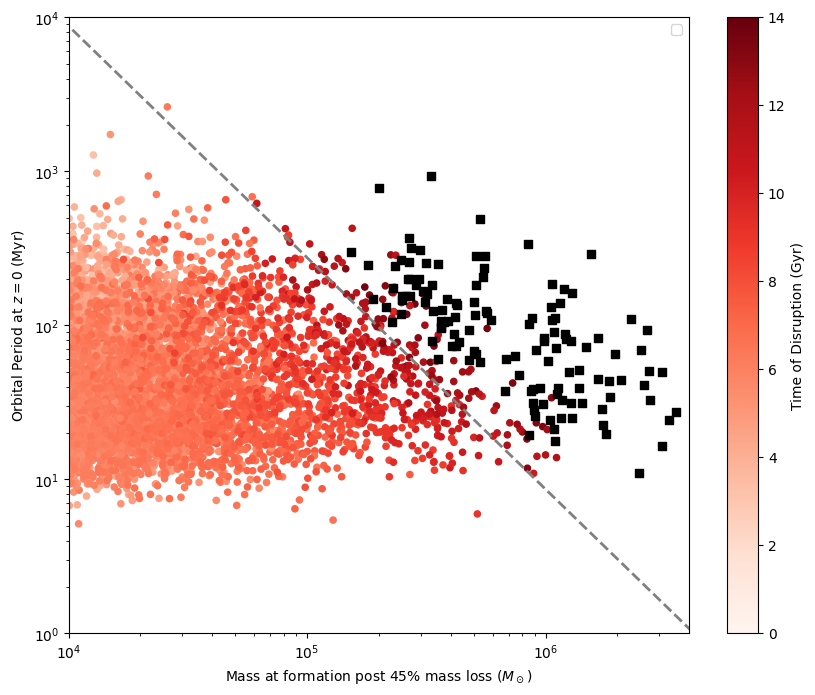

In [20]:
it_id = "it001"

msk_i = it_dict[it_id]["s_tz0"]

m_lst = []
b_lst = []

xfit = np.logspace(3, 7)
xfitlog = np.log10(xfit)

plt.figure(figsize=(10, 8))

# tdis_lst = [2, 4, 6, 7, 8, 10, 12]
tdis_lst = []
for tdis in tdis_lst:
    msk = (0 < it_dict[it_id]["tdis"]) & (it_dict[it_id]["tdis"] <= tdis)
    # msk = (0 < it_dict[it_id]["age_p"]) & (it_dict[it_id]["age_p"] <= tdis)
    x = it_dict[it_id]["m_tfo_ev"]
    y = it_dict[it_id]["t_tz0"]

    m, b = sep_func(x, y, msk)
    m_lst.append(m)
    b_lst.append(b)

    yfitlog = m * xfitlog + b
    yfit = 10**yfitlog

    plt.plot(xfit, yfit, label=tdis)


x_is = it_dict[it_id]["m_tfo_ev"][msk_i]
x_is = it_dict[it_id]["m_tfo"][msk_i]
y_is = it_dict[it_id]["t_tz0"][msk_i]
c_is = it_dict[it_id]["tdis"][msk_i]
# c_is = it_dict[it_id]["age_p"][msk_i]

x_id = it_dict[it_id]["m_tfo_ev"][~msk_i]
x_id = it_dict[it_id]["m_tfo"][~msk_i]
y_id = it_dict[it_id]["t_tz0"][~msk_i]
c_id = it_dict[it_id]["tdis"][~msk_i]
# c_id = it_dict[it_id]["age_p"][~msk_i]


plt.scatter(x_is, y_is, c="k", s=30, marker="s")
plt.scatter(x_id, y_id, c=c_id, s=20, cmap="Reds", vmin=0, vmax=14, zorder=0)
plt.colorbar(label="Time of Disruption (Gyr)")
# plt.colorbar(label="Age of Disruption (Gyr)")

plt.xscale("log")
plt.yscale("log")

# plt.xlim(0.55 * 10**4, 10**6.6)
plt.xlim(10**4, 10**6.6)
plt.ylim(10**0, 10**4)

plt.xlabel(r"Mass at formation post 45% mass loss ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

xfit = np.logspace(3, 7)
xfitlog = np.log10(xfit)

yfitlog = xfitlog * fit_dict[it_id]["m"] + fit_dict[it_id]["c"]
yfit = 10**yfitlog

plt.plot(xfit, yfit, c="grey", ls="--", lw=2)
plt.legend()

I think the plan now is to fully link this to the radial distribution of destroyed GCs and the contribution to the halo

# SETTLING TIME

In [21]:
def safe_interpolate(x, y, mass_grid):
    interp_func = interp1d(x, y, kind="previous", bounds_error=False, fill_value=(0, 1))
    return interp_func(mass_grid)


def get_cdf(arr):
    return np.cumsum(arr) / np.sum(arr)

In [22]:
it_id = "it001"

des_bins = np.linspace(0, 14, 1000)

msk = ~it_dict[it_id]["s_tz0"]
tdis = it_dict[it_id]["age_p"][msk]
death_cnt = len(tdis)
mass = it_dict[it_id]["m_tfo"][msk]

# plt.scatter(x, y)
# plt.yscale("log")

bin_frac = []
avg_mass = []
for i in range(1, len(des_bins)):
    bin_min = des_bins[i - 1]
    bin_max = des_bins[i]

    bin_msk = (bin_min <= tdis) & (tdis < bin_max)
    bin_frac.append(np.sum(bin_msk) / death_cnt)

    t_mass_msk = tdis < bin_max


(0.0, 1.0)

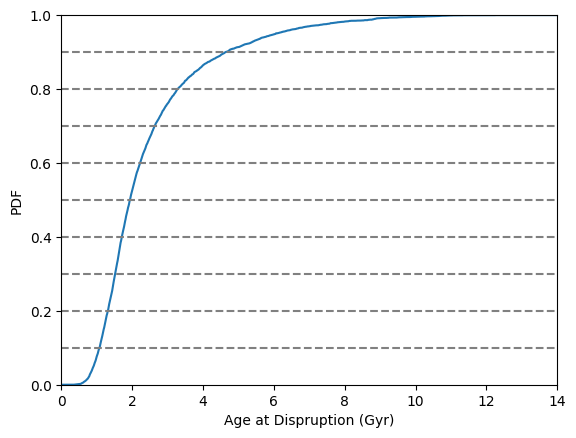

In [23]:
bins_cen = des_bins[:-1] + np.diff(des_bins) / 2
bin_frac_cum = np.cumsum(bin_frac)

plt.plot(bins_cen, bin_frac_cum)

plt.xlabel("Age at Dispruption (Gyr)")
plt.ylabel("PDF")

for target in np.linspace(0.1, 0.9, 9):
    plt.plot([0, 14], [target, target], ls="--", c="grey")

plt.xlim(0, 14)
plt.ylim(0, 1)

Text(0, 0.5, 'Mass at Formation (M$_\\odot$)')

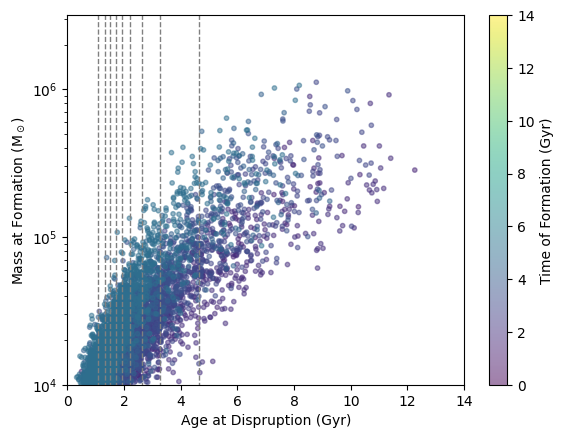

In [24]:
msk = ~it_dict[it_id]["s_tz0"]
# x = it_dict[it_id]["tdis"][msk]
x = it_dict[it_id]["age_p"][msk]
y = it_dict[it_id]["m_tfo"][msk]
# c = it_dict[it_id]["t_tz0"][msk]
c = it_dict[it_id]["tfor"][msk]

# plt.scatter(x, y, s=10)
# plt.scatter(x, y, s=10, c=c, norm=LogNorm(), alpha=0.5)
plt.scatter(x, y, s=10, c=c, alpha=0.5, vmin=0, vmax=14)
plt.colorbar(label="Time of Formation (Gyr)")
plt.yscale("log")

for target in np.linspace(0.1, 0.9, 9):
    t_at_target = np.interp(target, bin_frac_cum, bins_cen)

    plt.plot([t_at_target, t_at_target], [10**3, 10**7], c="grey", ls="--", lw=1)

plt.xlim(0, 14)
plt.ylim(10**4, 10**6.5)

plt.xlabel("Age at Dispruption (Gyr)")
plt.ylabel(r"Mass at Formation (M$_\odot$)")

When does increase start @ approx 4 GYr, maybe this is settlign time?

Text(0.5, 0, 'Orbital Period at $z=0 (Myr)')

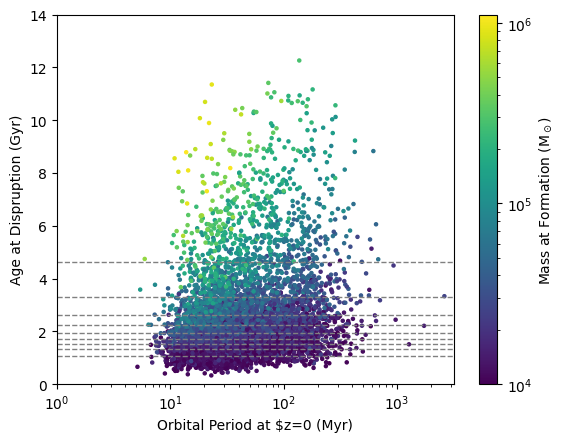

In [25]:
msk = ~it_dict[it_id]["s_tz0"]
# x = it_dict[it_id]["tdis"][msk]
y = it_dict[it_id]["age_p"][msk]
x = it_dict[it_id]["m_tfo"][msk]
c = it_dict[it_id]["t_tz0"][msk]

# plt.scatter(x, y, c=c, s=5, norm=LogNorm())
plt.scatter(c, y, c=x, s=5, norm=LogNorm())
# plt.scatter(c, y, s=5)
plt.colorbar(label=r"Mass at Formation (M$_\odot$)")
plt.xscale("log")

for target in np.linspace(0.1, 0.9, 9):
    t_at_target = np.interp(target, bin_frac_cum, bins_cen)

    plt.plot([10**0, 10**7], [t_at_target, t_at_target], c="grey", ls="--", lw=1)

plt.ylim(0, 14)
# plt.xlim(10**4, 10**6.5)
plt.xlim(10**0, 10**3.5)

plt.ylabel("Age at Dispruption (Gyr)")
plt.xlabel("Orbital Period at $z=0 (Myr)")

Text(0, 0.5, 'Fraction of Disrupted GCs')

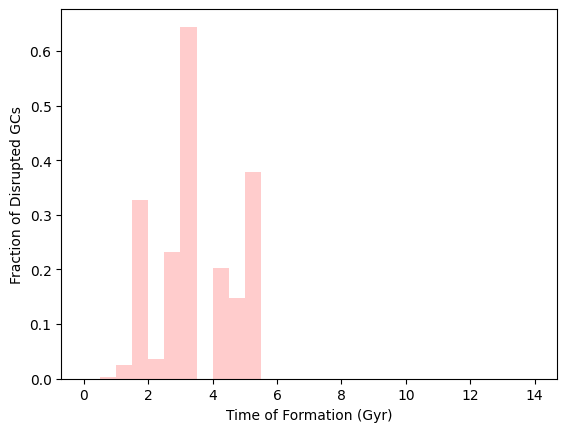

In [26]:
xlab = "tfor"  # "tfor", "age_p"
sur_msk = it_dict[it_id]["s_tz0"]
# tfor_msk = it_dict[it_id]["tfor"] < 9
x = it_dict[it_id][xlab]
x_dat = x[~sur_msk]

xbins = np.arange(0, 14.5, 0.5)
plt.hist(x_dat, bins=xbins, density=True, color="red", alpha=0.2)

plt.xlabel("Time of Formation (Gyr)")
plt.ylabel("Fraction of Disrupted GCs")

0.7387794010089125 0.5616710309629357


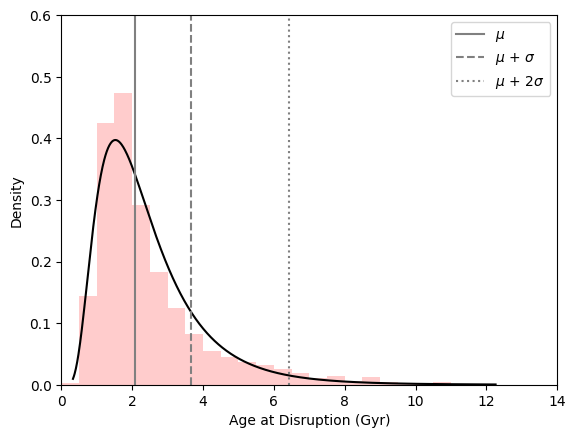

In [27]:
xlab = "age_p"  # "tfor", "age_p"
sur_msk = it_dict[it_id]["s_tz0"]
# tfor_msk = it_dict[it_id]["tfor"] < 9
x = it_dict[it_id][xlab]

x_dat = x[~sur_msk]
# x_dat = x[~sur_msk & tfor_msk]

# Fit lognormal
shape, loc, scale = lognorm.fit(x_dat, floc=0)  # force loc=0

sigma = shape
mu = np.log(scale)

print(mu, sigma)

xgrid = np.linspace(min(x_dat), max(x_dat), 1000)
pdf = lognorm.pdf(xgrid, shape, loc=loc, scale=scale)
plt.plot(xgrid, pdf, c="black")

xbins = np.arange(0, 14.5, 0.5)
plt.hist(x_dat, bins=xbins, density=True, color="red", alpha=0.2)

plt.xlim(0, 14)
plt.ylim(0, 0.6)

plt.xlabel("Age at Disruption (Gyr)")
plt.ylabel("Density")

x_plus_1sigma = np.exp(mu + sigma)
x_plus_2sigma = np.exp(mu + 2 * sigma)
# x_minus_1sigma = np.exp(mu - sigma)

plt.plot(np.exp([mu, mu]), [0, 1], label=r"$\mu$", c="grey", ls="-")
plt.plot([x_plus_1sigma, x_plus_1sigma], [0, 1], label=r"$\mu$ + $\sigma$", c="grey", ls="--")
plt.plot([x_plus_2sigma, x_plus_2sigma], [0, 1], label=r"$\mu$ + 2$\sigma$", c="grey", ls=":")

plt.legend()

(3.6590324624102637, 0.15769095782878703)

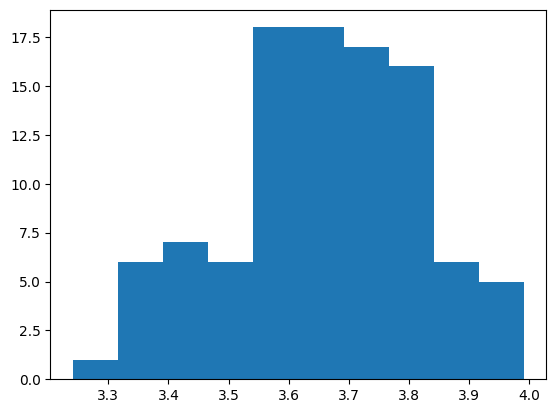

In [28]:
xlab = "age_p"  # "tfor", "age_p"

# tfor_msk = it_dict[it_id]["tfor"] < 9

x_plus_sig_lst = []
for it_id in it_dict.keys():
    sur_msk = it_dict[it_id]["s_tz0"]
    x = it_dict[it_id][xlab]

    x_dat = x[~sur_msk]
    # x_dat = x[~sur_msk & tfor_msk]

    # Fit lognormal
    shape, loc, scale = lognorm.fit(x_dat, floc=0)  # force loc=0

    sigma = shape
    mu = np.log(scale)

    x_plus_1sigma = np.exp(mu + sigma)
    # x_minus_1sigma = np.exp(mu - sigma)

    x_plus_sig_lst.append(x_plus_1sigma)

plt.hist(x_plus_sig_lst)

np.mean(x_plus_sig_lst), np.std(x_plus_sig_lst)

Text(0, 0.5, 'Fraction of Disrupted GCs')

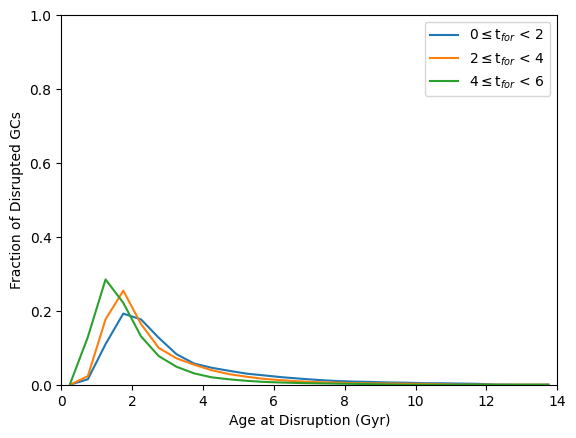

In [29]:
xlab = "age_p"
xbins = np.arange(0, 14.5, 0.5)
tfor_bins = np.arange(0, 16, 2)

# Store global counts
global_counts = {i: np.zeros(len(xbins) - 1) for i in range(1, len(tfor_bins))}
global_totals = {i: 0 for i in range(1, len(tfor_bins))}

# ---- Loop over ALL it_id ----
for it_id in it_dict.keys():
    sur_msk = ~it_dict[it_id]["s_tz0"]
    x = it_dict[it_id][xlab]
    tfor = it_dict[it_id]["tfor"]

    for i in range(1, len(tfor_bins)):
        tfor_min = tfor_bins[i - 1]
        tfor_max = tfor_bins[i]

        tfor_msk = (tfor_min <= tfor) & (tfor < tfor_max)
        combined_msk = sur_msk & tfor_msk

        tfor_cnt = np.sum(combined_msk)

        if tfor_cnt == 0:
            continue

        global_totals[i] += tfor_cnt

        for j in range(1, len(xbins)):
            x_min = xbins[j - 1]
            x_max = xbins[j]
            x_msk = (x_min <= x) & (x < x_max)

            bin_cnt = np.sum(combined_msk & x_msk)

            global_counts[i][j - 1] += bin_cnt


bin_cen = xbins[:-1] + np.diff(xbins) / 2

for i in global_counts.keys():
    if global_totals[i] == 0:
        continue

    frac = global_counts[i] / global_totals[i]

    label = str(tfor_bins[i - 1]) + r"$\leq$" + r"t$_{for}$ < " + str(tfor_bins[i])

    plt.plot(bin_cen, frac, label=label)

plt.legend()
plt.xlim(0, 14)
plt.ylim(0, 1)

plt.xlabel("Age at Disruption (Gyr)")
plt.ylabel("Fraction of Disrupted GCs")

In [30]:
xlab = "age_p"
# xbins = np.arange(0, 14.5, 0.5)
tfor_bins = np.arange(0, 16, 2)

data_dict = {i: [] for i in range(1, len(tfor_bins))}
for it_id in it_dict.keys():
    sur_msk = ~it_dict[it_id]["s_tz0"]
    x = it_dict[it_id][xlab]
    tfor = it_dict[it_id]["tfor"]

    for i in range(1, len(tfor_bins)):
        tfor_min = tfor_bins[i - 1]
        tfor_max = tfor_bins[i]

        tfor_msk = (tfor_min <= tfor) & (tfor < tfor_max)

        msk = sur_msk & tfor_msk
        if sum(msk) == 0:
            data_dict[i].append(np.nan)
            continue

        else:
            x_dat = x[msk]

            # Fit lognormal
            shape, loc, scale = lognorm.fit(x_dat, floc=0)  # force loc=0

            sigma = shape
            mu = np.log(scale)

            x_plus_1sigma = np.exp(mu + sigma)

            data_dict[i].append(x_plus_1sigma)

for i in data_dict.keys():
    label = str(tfor_bins[i - 1]) + r"$\leq$" + r"t$_{for}$ < " + str(tfor_bins[i])

    mean = np.nanmean(data_dict[i])
    std = np.nanstd(data_dict[i])

    print(label, ":", mean, std)

0$\leq$t$_{for}$ < 2 : 4.713188309441708 0.09736113593215001
2$\leq$t$_{for}$ < 4 : 3.8470132444403977 0.08871399925403589
4$\leq$t$_{for}$ < 6 : 2.9665814926797727 0.08600975735766196
6$\leq$t$_{for}$ < 8 : nan nan
8$\leq$t$_{for}$ < 10 : nan nan
10$\leq$t$_{for}$ < 12 : nan nan
12$\leq$t$_{for}$ < 14 : nan nan


/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_90070/4169694516.py:38: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(data_dict[i])
/Users/z5114326/Documents/GitHub/ghost_accretions/.venv312/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


(10000, 10000000)

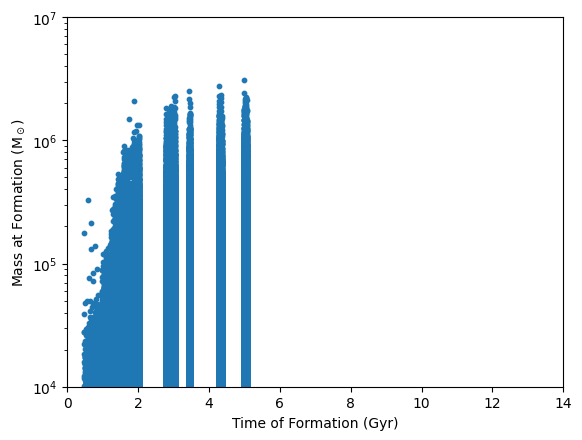

In [31]:
x = np.array([])
y = np.array([])

for it_id in it_dict.keys():
    msk = it_dict[it_id]["s_tz0"]
    xi = it_dict[it_id]["tfor"][~msk]
    yi = it_dict[it_id]["m_tfo"][~msk]

    x = np.concatenate((x, xi))
    y = np.concatenate((y, yi))

plt.scatter(x, y, s=10)
plt.yscale("log")

plt.xlabel("Time of Formation (Gyr)")
plt.ylabel(r"Mass at Formation (M$_\odot$)")

plt.xlim(0, 14)
plt.ylim(10**4, 10**7)

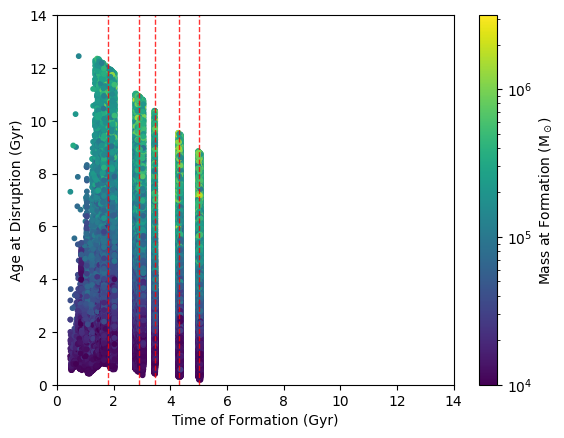

In [32]:
x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk = it_dict[it_id]["s_tz0"]
    xi = it_dict[it_id]["tfor"][~msk]
    yi = it_dict[it_id]["age_p"][~msk]
    ci = it_dict[it_id]["m_tfo"][~msk]

    x = np.concatenate((x, xi))
    y = np.concatenate((y, yi))
    c = np.concatenate((c, ci))

plt.scatter(x, y, s=10, c=c, norm=LogNorm(vmin=10**4, vmax=10**6.5))
plt.colorbar(label=r"Mass at Formation (M$_\odot$)")
# plt.yscale("log")

plt.xlabel("Time of Formation (Gyr)")
plt.ylabel("Age at Disruption (Gyr)")

plt.xlim(0, 14)
plt.ylim(0, 14)

time_dict = {"m12b": [1, 2.3, 3.1], "m12i": [1.5, 3, 4.3, 5]}
# times = time_dict[sim]
# for time in times:
#     plt.plot([time, time], [0, 14], c="r")

x_sorted = np.sort(x)

# Find gaps between neighbouring x values
dx = np.diff(x_sorted)

# Threshold to detect a jump between sections
threshold = 0.1  # adjust if needed, was 0.05

# Indices where a new section starts
section_breaks = np.where(dx > threshold)[0] + 1

# Split into sections
sections = np.split(x_sorted, section_breaks)

# Compute centre of each section
x_sections = [np.mean(sec) for sec in sections]

# Draw vertical lines
for xv in x_sections:
    plt.axvline(x=xv, color="red", linewidth=1, alpha=0.8, ls="--")


Text(0, 0.5, 'Mass at Formation (M$_\\odot$)')

Error in callback <function _draw_all_if_interactive at 0x12dc654e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

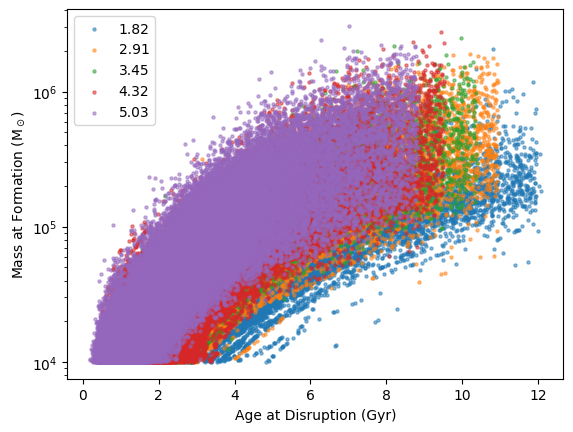

In [33]:
threshold = 0.1

for xv in x_sections:
    msk = (xv - threshold < x) & (x < xv + threshold)

    age_dis = y[msk]
    m_for = c[msk]

    plt.scatter(age_dis, m_for, alpha=0.5, label=np.round(xv, 2), s=5)

plt.yscale("log")
plt.legend()

plt.xlabel("Age at Disruption (Gyr)")
plt.ylabel(r"Mass at Formation (M$_\odot$)")


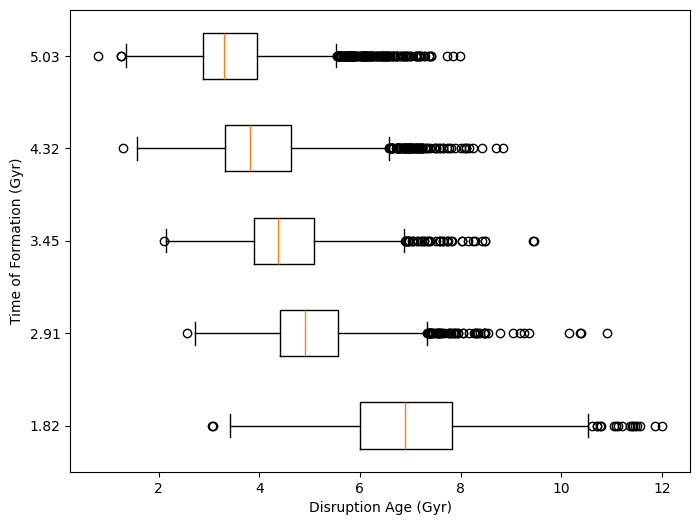

In [ ]:
mass_test = 10**5
mass_thresh = 0.1

box_data = []
labels = []

for xv in x_sections:
    msk = (xv - threshold < x) & (x < xv + threshold)

    age_dis = y[msk]
    m_for = c[msk]

    mass_msk = ((1 - mass_thresh) * mass_test < m_for) & (m_for < (1 + mass_thresh) * mass_test)

    age_dis_mskd = age_dis[mass_msk]
    age_dis_mskd = age_dis_mskd[~np.isnan(age_dis_mskd)]

    if len(age_dis_mskd) > 0:
        box_data.append(age_dis_mskd)
        labels.append(xv)

plt.figure(figsize=(8, 6))
plt.boxplot(box_data, vert=False)

plt.yticks(range(1, len(labels) + 1), np.round(labels, 2))
plt.xlabel("Disruption Age (Gyr)")
plt.ylabel("Time of Formation (Gyr)")

plt.show()


In [ ]:
# x = np.array([])
# y = np.array([])
# c = np.array([])

# for it_id in it_dict.keys():
#     msk = it_dict[it_id]["s_tz0"]
#     ci = it_dict[it_id]["tfor"][~msk]
#     yi = it_dict[it_id]["age_p"][~msk]
#     xi = it_dict[it_id]["m_tfo"][~msk]

#     x = np.concatenate((x, xi))
#     y = np.concatenate((y, yi))
#     c = np.concatenate((c, ci))

# plt.scatter(x, y, s=10, c=c, vmin=0, vmax=14)
# plt.colorbar(label="Time of Formation (Gyr)")
# plt.xscale("log")

# plt.xlabel(r"Mass at Formation (M$_\odot$)")
# plt.ylabel("Age at Disruption (Gyr)")

# plt.xlim(10**4, 10**6.5)
# plt.ylim(0, 14)